# EDA Part 3 — Analyse temporelle

Analyser les patterns temporels : volume par heure/jour, pics d’activité, saisonnalité. Créer des graphiques de séries temporelles. Identifier les fenêtres d’activité potentiellement suspectes.

## 0. Imports & Chargement

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

Libraries loaded ✅


In [2]:
unsw_columns = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur',
    'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service',
    'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb',
    'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt',
    'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
    'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'
]

chemin_CICIDS = '../Data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
chemin_UNSW   = '../Data/UNSW-NB15_1.csv'
chemin_LOGS   = '../Data/cybersecurity_threat_detection_logs.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,names=unsw_columns, low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS, low_memory=False)


## 1. CIC-IDS-2017



### 1.1 Distribution de la durée des flux

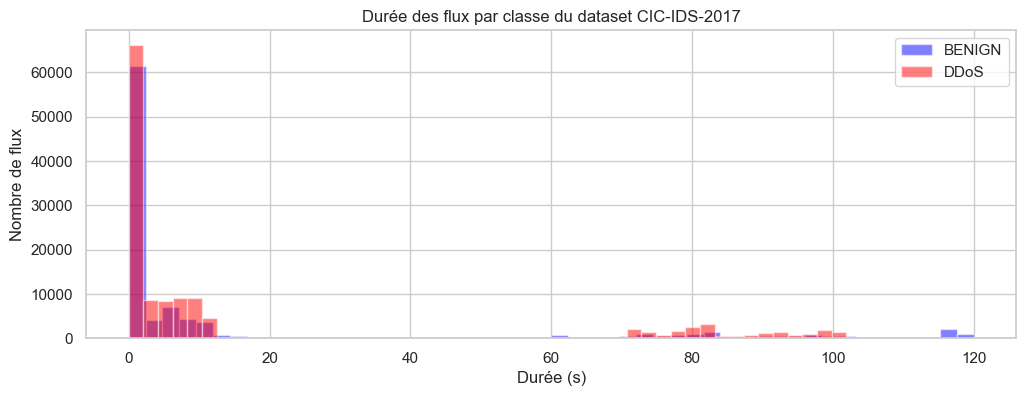

In [28]:
df_cicids_clean = df_cicids[df_cicids[' Flow Duration'] >= 0].copy() # enlever les valeurs aberrantes (-1) 
df_cicids_clean[' Flow Duration (s)'] = df_cicids_clean[' Flow Duration'] / 1_000_000 # convertir ms en s
for label, group in df_cicids_clean.groupby(' Label'):
   group[' Flow Duration (s)'].hist(bins=50, alpha=0.5, label=label, color='red' if label == 'DDoS' else 'blue')
plt.title('Durée des flux par classe du dataset CIC-IDS-2017')
plt.xlabel('Durée (s)')
plt.ylabel('Nombre de flux')
plt.legend()
plt.show()

Le graphique confirme une différence temporelle claire entre le trafic DDoS et le trafic normal (BENIGN).
La quasi-totalité des flux DDoS sont concentrés entre 0 et 10 secondes, avec un pic massif à moins d'1 seconde où il y a plus de 60 000 connexions. C'est la signature typique d'une attaque DDoS qui génère un maximum de connexions très courtes pour saturer le serveur rapidement.
Le trafic BENIGN (bleu) est quasi invisible sur ce graphique car il représente une très faible minorité du dataset, ce qui confirme le fort déséquilibre des classes identifié précédemment.
On observe également une deuxième concentration de flux DDoS entre 60 et 120 secondes, ce qui représente des connexions maintenues plus longtemps et donc potentiellement un autre type de comportement d'attaque au sein du même dataset.
Ainsi une fenêtre suspecte serait toute connexion de moins d'1 seconde vers le port 80, très probablement malveillante. La durée du flux est donc une feature importante à conserver pour la modélisation.

### 1.2 Identification des fenêtres suspectes

In [30]:
# Flux courts donc inférieur à 0.1s 
flux_courts = df_cicids_clean[df_cicids_clean[' Flow Duration (s)'] < 0.1]
print(f'Flux courts : {len(flux_courts):,}')
print(flux_courts[' Label'].value_counts())

# Flux longs donc supérieur à 60s
flux_longs = df_cicids_clean[df_cicids_clean[' Flow Duration (s)'] > 60]
print(f'\nFlux longs : {len(flux_longs):,}')
print(flux_longs[' Label'].value_counts())

Flux courts : 61,408
 Label
BENIGN    45761
DDoS      15647
Name: count, dtype: int64

Flux longs : 35,480
 Label
DDoS      21458
BENIGN    14022
Name: count, dtype: int64


On remarque que les flux courts ici inférieur à  0.1s possèdent  61 408 connexions.
Sur les 61 408 flux très courts, 45 761 sont BENIGN et 15 647 sont DDoS. Contrairement à ce qu'on pourrait attendre, les connexions ultra-courtes ne sont pas exclusivement malveillantes ainsi le trafic normal génère aussi beaucoup de connexions rapides. 
Pour les flux longs de plus de 60s il y a au total 35 480 connexions.
Sur les 35 480 flux longs, 21 458 sont DDoS et 14 022 sont BENIGN.Ainsi les connexions longues sont majoritairement DDoS . Cela correspond au comportement observé sur le graphique précédent avec la concentration de flux DDoS entre 60 et 120 secondes.
Ainsi ici la fenêtre la plus suspecte est donc celle des connexions longues où le DDoS domine.


### 1.3 Connexions vers le port 80 uniquement

In [32]:
port80 = df_cicids_clean[df_cicids_clean[' Destination Port'] == 80]
print(f'Connexions vers port 80 : {len(port80):,}')
print(port80[' Label'].value_counts())

Connexions vers port 80 : 136,950
 Label
DDoS      128024
BENIGN      8926
Name: count, dtype: int64


Sur les 136 950 connexions vers le port 80, 128 024 sont DDoS contre seulement 8 926 BENIGN . Le port 80 est donc une fenêtre d'activité clairement suspecte dans ce dataset car la quasi-totalité du trafic HTTP est malveillant, ce qui confirme que l'attaque DDoS cible spécifiquement les services web.

### 1.4 Taille moyenne des paquets par classe

In [40]:
print(df_cicids_clean.groupby(' Label')['Total Length of Fwd Packets'].mean())

 Label
BENIGN    2128.556009
DDoS        31.908597
Name: Total Length of Fwd Packets, dtype: float64


On remarque une forte différence entre les paquets BENIGN qui font en moyenne 2128 octets contre seulement 31 octets pour les DDoS. Les paquets DDoS sont donc 70 fois plus petits que le trafic normal. Ici l'objectif est de saturer le serveur en le forçant à gérer des milliers de connexions fantômes en attente.

### 1.5 Connexions inférieure à 1s vers le port 80

In [44]:
suspects = df_cicids_clean[
    (df_cicids_clean[' Destination Port'] == 80) & (df_cicids_clean[' Flow Duration (s)'] < 1)]
print(f'Connexions inférieure à 1s vers le port 80 : {len(suspects):}')
print(suspects[' Label'].value_counts())

Connexions inférieure à 1s vers le port 80 : 48129
 Label
DDoS      43350
BENIGN     4779
Name: count, dtype: int64


En combinant les deux indicateurs, on identifie 48 129 connexions suspectes dont 43 350 DDoS et seulement 4 779 BENIGN . Cette combinaison de connexions inférieure à 1s vers le port 80 est donc la fenêtre suspecte la plus fiable du dataset où à peu près 9 connexions sur 10 respectant ces critères sont des attaques.


## 2. UNSW-NB15


### 2.1 Conversion des timestamps afin d'exploiter les dates

In [46]:
df_unsw['datetime'] = pd.to_datetime(df_unsw['Stime'], unit='s', errors='coerce') # convertir les secondes en date
df_unsw = df_unsw.dropna(subset=['datetime']) # supprimer les dates invalides

# On extrait heure, jour et nom du jour
df_unsw['heure']= df_unsw['datetime'].dt.hour
df_unsw['jour']= df_unsw['datetime'].dt.date
df_unsw['jour_semaine'] = df_unsw['datetime'].dt.day_name()

print(f'Période de {df_unsw["datetime"].min()} à {df_unsw["datetime"].max()}')
print(f'Jours distincts : {df_unsw["jour"].nunique()}')

Période : 2015-01-22 11:49:37 à 2015-01-22 19:44:02
Jours distincts : 1


Comme le dataset UNSW-NB15 n'est que sur une seule journée on en conclut qu'une analyse par jour n'est pas pertinente.

### 2.2 Volume par heure

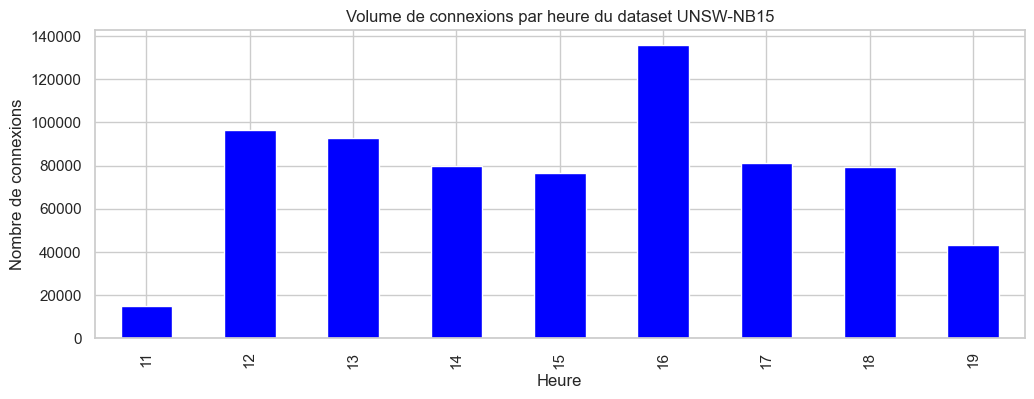

In [51]:
fig, ax = plt.subplots()
volume_heure = df_unsw.groupby('heure').size()
volume_heure.plot(kind='bar',color='blue')
ax.set_title('Volume de connexions par heure du dataset UNSW-NB15')
ax.set_xlabel('Heure')
ax.set_ylabel('Nombre de connexions')
plt.show()

Le trafic est concentré entre 11h et 19h, avec un pic marqué à 16h avec environ 135 000 connexions, soit 9 fois plus qu'à 11h.
Ce pic brutal et isolé constitue la fenêtre d'activité la plus suspecte du dataset car un volume aussi élevé sur une heure précise est suspect.
En dehors de 16h, le volume reste stable entre 75 000 et 95 000 connexions.

### 2.3 Trafic normal et malveillant par heure

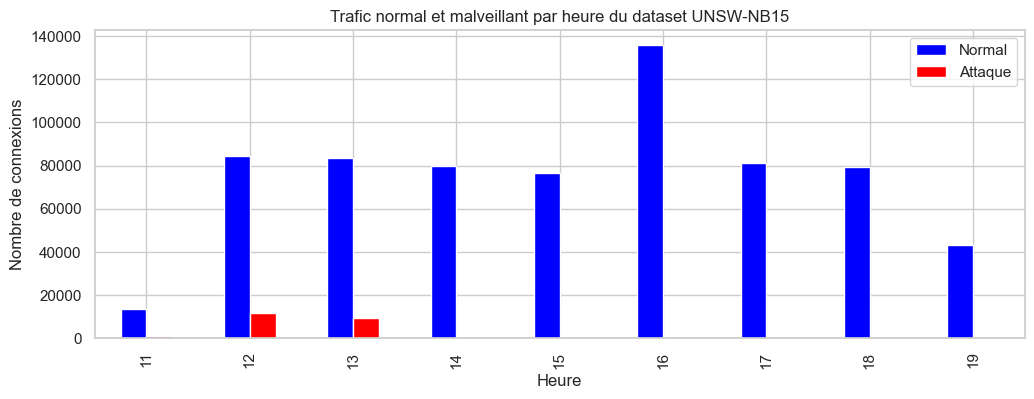

heure
12    11734
13     9331
11     1150
14        0
15        0
Name: Attaque, dtype: int64


In [59]:
attaques_heure = df_unsw.groupby(['heure', 'Label']).size().unstack(fill_value=0)
attaques_heure.columns = ['Normal', 'Attaque']
attaques_heure.plot(kind='bar', color=['blue', 'red'])
plt.title('Trafic normal et malveillant par heure du dataset UNSW-NB15')
plt.xlabel('Heure')
plt.ylabel('Nombre de connexions')
plt.show()

# Les 5 heures les plus attaquées
print(attaques_heure['Attaque'].sort_values(ascending=False).head())

Le trafic est plutôt normal sur toute la journée. Les attaques n'apparaissent qu'à 12h et 13h, formant une fenêtre suspecte courte et ciblée.
Le pic de 16h, précédemment identifié comme suspect, est en réalité un trafic normal . Les attaques se concentrent en début d'après-midi pour se fondre dans le trafic normal.

### 2.4 Type d'attaque par heure

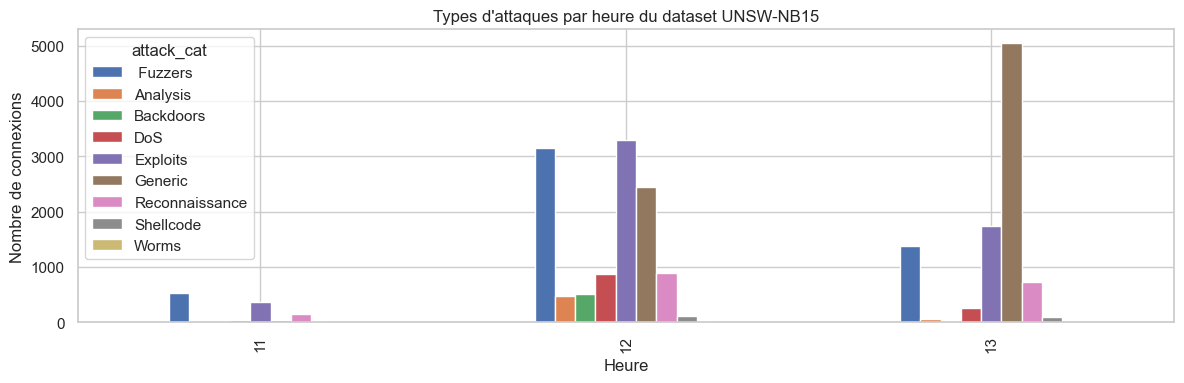

In [65]:
df_unsw[df_unsw['Label']==1].groupby(['heure', 'attack_cat']).size().unstack(fill_value=0).plot(kind='bar')
plt.title('Types d\'attaques par heure du dataset UNSW-NB15')
plt.xlabel('Heure')
plt.ylabel('Nombre de connexions')
plt.tight_layout()
plt.show()

Les attaques sont concentrées sur 11h, 12h et 13h uniquement et donc confirmant la fenêtre suspecte identifiée précédemment.
On remarque que à 11h ne présente que des traces mineures de Fuzzers et Exploits, il s'agit probablement une phase de reconnaissance avant l'attaque principale de 12h. Car à 12h il s'agit de l l'heure la plus critique car on y retrouve tous les types d'attaques simultanément, avec une dominance des attaques Fuzzers et Exploits .A 13h on retrouve plutôt les attaques Generic qui deviennent largement dominantes.


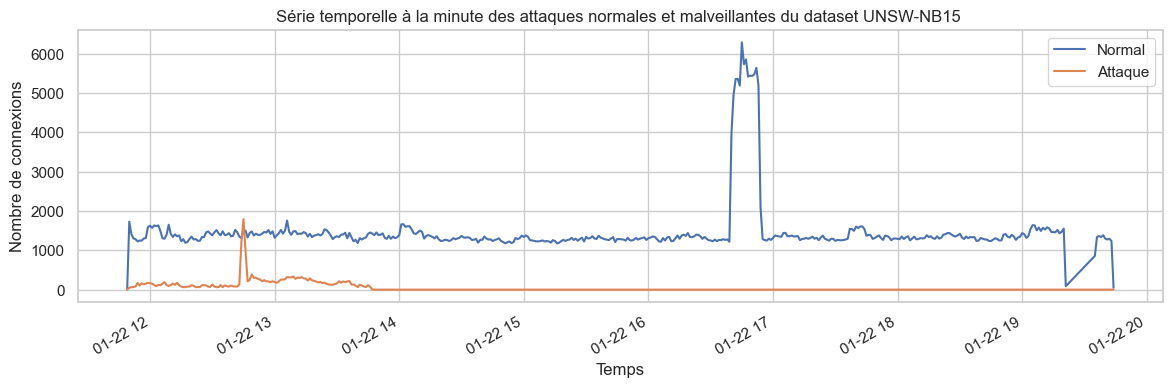

In [71]:
df_unsw['minute'] = df_unsw['datetime'].dt.floor('min')
ax = df_unsw.groupby(['minute', 'Label']).size().unstack(fill_value=0).plot(kind='line', figsize=(14,4))
ax.legend(['Normal', 'Attaque'])
plt.title('Série temporelle à la minute des attaques normales et malveillantes du dataset UNSW-NB15 ')
plt.xlabel('Temps')
plt.ylabel('Nombre de connexions')
plt.show()

Le trafic normal (bleu) est stable et continu autour de 1000 à 1500 connexions par minute sur toute la journée,même si on remarque un pic brutal à 17h avec environ 6000 connexion par minute ce qui peut représenter une fenêtre suspecte de la série.
Les attaques (orange) sont concentrées entre 12h et 13h, puis disparaissent totalement et confirme donc une période courte et ciblée.
Les deux anomalies majeures sont donc bien distinctes soient les attaques à 12h-13h et le pic de trafic normal à 17h.


## 3. Cybersecurity Threat Detection Logs


### 3.1 Conversion des timestamps

In [73]:
df_logs['datetime'] = pd.to_datetime(df_logs['timestamp'], errors='coerce')
df_logs = df_logs.dropna(subset=['datetime'])
df_logs['heure']= df_logs['datetime'].dt.hour
df_logs['jour']= df_logs['datetime'].dt.date
df_logs['mois']= df_logs['datetime'].dt.month
df_logs['jour_semaine'] = df_logs['datetime'].dt.day_name()
print(f'Période de {df_logs["datetime"].min()} à {df_logs["datetime"].max()}')

Période de 2024-01-01 00:00:00 à 2024-12-30 00:00:00


### 3.2 Volume par mois

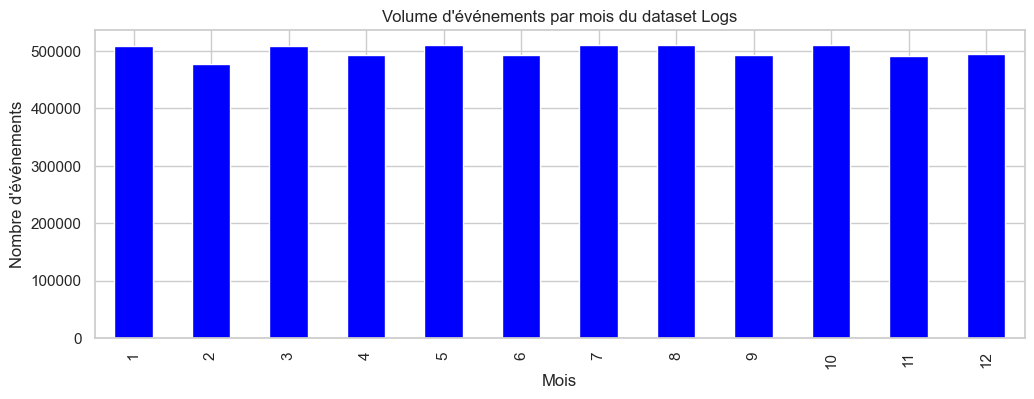

In [78]:
df_logs.groupby('mois').size().plot(kind='bar', color='blue')
plt.title('Volume d\'événements par mois du dataset Logs')
plt.xlabel('Mois')
plt.ylabel('Nombre d\'événements')
plt.show()

### 3.3 Volume par jour de la semaine

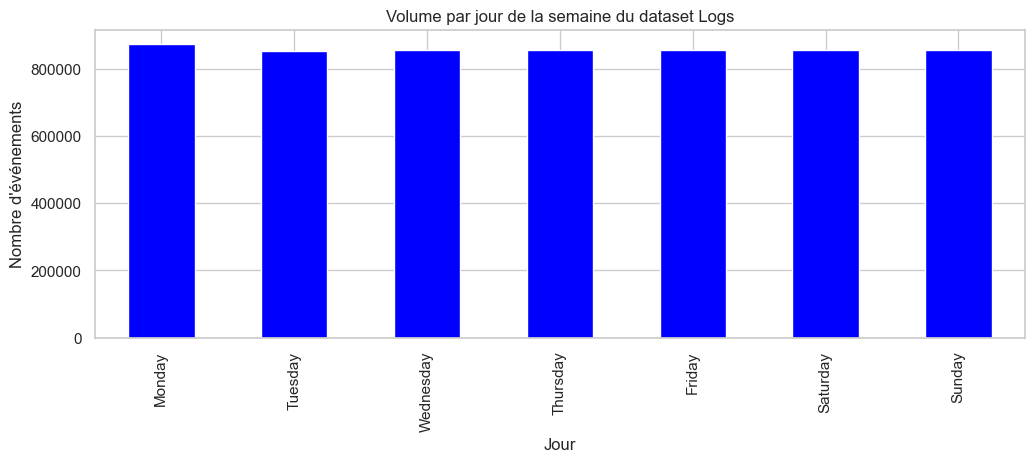

In [79]:
df_logs.groupby('jour_semaine').size().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar', color='blue')
plt.title('Volume par jour de la semaine du dataset Logs')
plt.xlabel('Jour')
plt.ylabel('Nombre d\'événements')
plt.show()

On ne remarque aucune grande variations entre les mois ou jours de la semaine ce qui est cohérent avec le fait que ce dataset est synthétique.

### 3.4 Distribution des menaces par mois

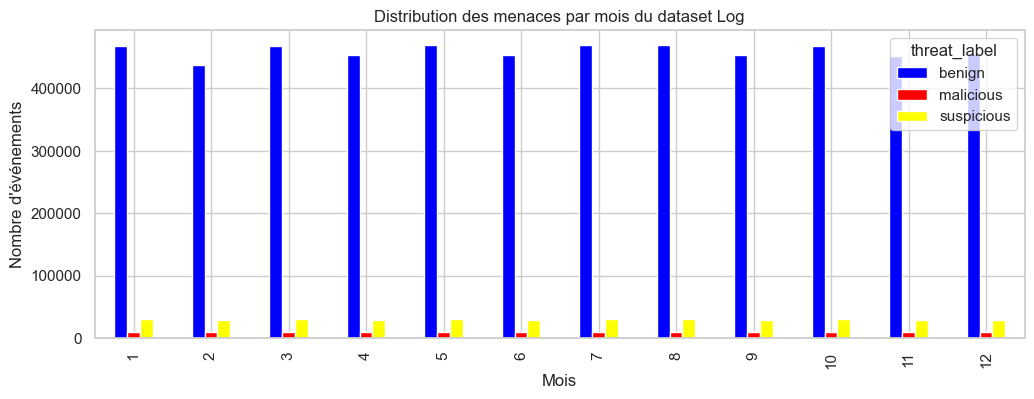

mois
10    10501
8     10460
3     10411
1     10314
7     10222
Name: malicious, dtype: int64


In [87]:
classes_mois = df_logs.groupby(['mois', 'threat_label']).size().unstack(fill_value=0)
classes_mois.plot(kind='bar', color=['blue', 'red', 'yellow'])
plt.title('Distribution des menaces par mois du dataset Log')
plt.xlabel('Mois')
plt.ylabel('Nombre d\'événements')
plt.show()

# Mois avec le plus d'événements malveillants
if 'malicious' in classes_mois.columns:
    print(classes_mois['malicious'].sort_values(ascending=False).head())

Ici le trafic bénin est largement au dessus avec 450 000 événements par mois contre 10 000 malveillants et 20 000 suspects.
Les trois catégories sont parfaitement stables sur les 12 mois, sans aucun pic ni creux notable. Le mois d'octobre présente légèrement plus d'événements malveillants (10 501) mais l'écart n'est pas flagrant.

### 3.5 Les jours avec le plus d'événements malveillants

Les jours avec le plus d'événements malveillants :
jour
2024-08-09    407
2024-03-19    390
2024-09-07    380
2024-04-05    371
2024-08-15    370
2024-01-28    369
2024-02-29    368
2024-10-13    367
2024-01-11    366
2024-04-28    365
dtype: int64


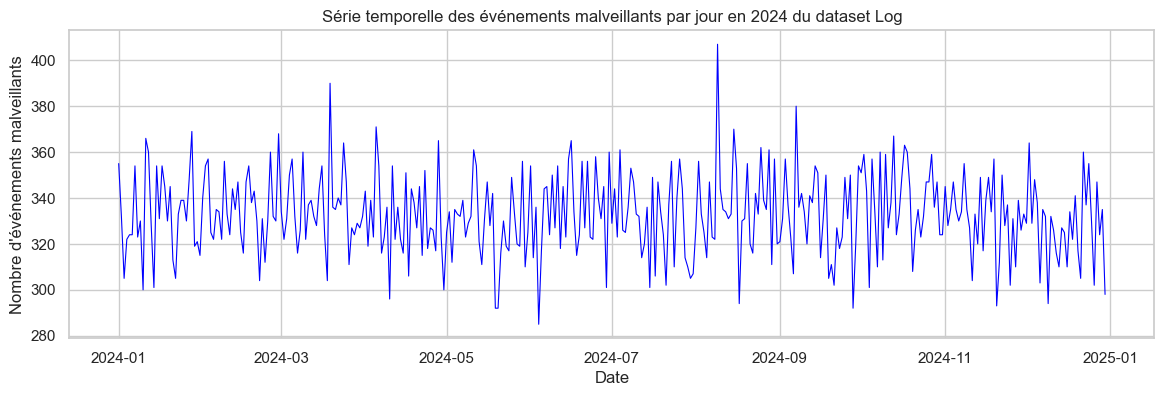

In [91]:
malveillants_jour = df_logs[df_logs['threat_label'] == 'malicious'].groupby('jour').size()
print('Les jours avec le plus d\'événements malveillants :')
print(malveillants_jour.sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(14, 4))
malveillants_jour.plot(kind='line',color='blue', linewidth=0.8)
ax.set_title('Série temporelle des événements malveillants par jour en 2024 du dataset Log')
ax.set_xlabel('Date')
ax.set_ylabel('Nombre d\'événements malveillants')
plt.show()

Le volume quotidien d'attaques oscille entre 280 et 407 événements par jour, avec aucune tendance à la hausse ou à la baisse.
Le jour le plus attaqué est le 9 août 2024 (407 événements), suivi du 19 mars et du 7 septembre. 

On a remarqué que les analyses précédentesn'ont révélé aucun pattern exploitable, le trafic restait plutôt stable.
Cette fois-ci plutôt que de compter les événements bruts, on applique une moyenne mobile sur 7 jours uniquement sur le trafic malveillant. Cette technique lisse le bruit quotidien.
Ainsi au lieu de regarder chaque jour individuellement, on regarde comment évolue la moyenne des 7 derniers jours.

### 3.6 Moyenne mobile sur 7 jours pour lisser le bruit

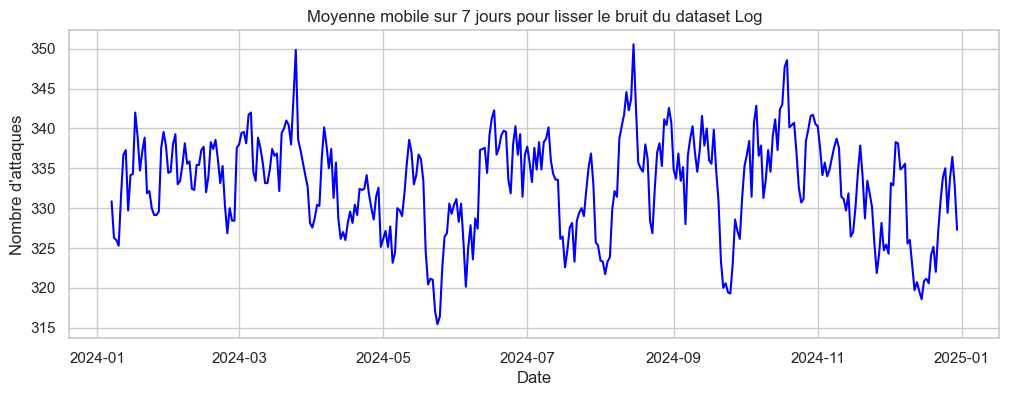

In [93]:
malveillants_jour = df_logs[df_logs['threat_label'] == 'malicious'].groupby('jour').size()
malveillants_jour.rolling(7).mean().plot(color='blue', linewidth=1.5)
plt.title('Moyenne mobile sur 7 jours pour lisser le bruit du dataset Log')
plt.xlabel('Date')
plt.ylabel('Nombre d\'attaques')
plt.show()

Ici le volume d'attaques oscille entre 315 et 350, avec des cycles réguliers de 3 à 4 semaines sur toute l'année.
Cependant on remarque un premier pic majeur en Avril puis en Septembre avec le pic le plus élevé et finalement en novembre.
Mais aussi un creux en juin-juillet montrant une baisse d'activité malveillante en milieu d'année.


### Conclusion

En conclusion le dataset CIC-IDS-2017 révèle des fenêtres suspectes via la durée et le port des flux, le dataset UNSW-NB15 identifie une suite d'attaque ciblée sur 12h-13h et le dataset Logs,lui synthétique, ne révèle pas de patterns en général sauf que via la moyenne mobile. Chaque dataset nécessite donc une approche temporelle adaptée à sa structure.